# Bike Sharing Demand — Exploratory Data Analysis

**Dataset:** UCI Bike Sharing Dataset (`hour.csv`)  
**Goal:** Understand the structure of the data, identify temporal and weather-driven patterns in hourly bike demand, and surface insights that will inform feature engineering and model selection.

---

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Target Variable Distribution](#3-target-variable-distribution)
4. [Temporal Patterns](#4-temporal-patterns)
5. [Weather Effects](#5-weather-effects)
6. [Trend Over Time](#6-trend-over-time)
7. [Correlation Analysis](#7-correlation-analysis)
8. [Holiday Effect](#8-holiday-effect)
9. [Data Quality Check](#9-data-quality-check)
10. [Key Takeaways](#10-key-takeaways)

## 1. Setup & Data Loading

Standard imports and dataset loading. We work with `hour.csv`, the hourly-level granularity file, which is the primary target for demand forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 2. Dataset Overview

Before any analysis, we inspect the shape, date range, and data types to understand what we are working with and catch any obvious issues early.

In [3]:
print(f'Data shape: {df.shape}')
print(f'Date range: {df["dteday"].min()} → {df["dteday"].max()}')

Data shape: (17379, 17)
Date range: 2011-01-01 → 2012-12-31


In [4]:
print(f'Data types:\n{df.dtypes}')

Data types:
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


## 3. Target Variable Distribution

We examine the distribution of `cnt` (total rentals per hour) — our prediction target. Understanding its shape helps us decide whether to model it directly or apply a transformation (e.g. log-transform) before training.

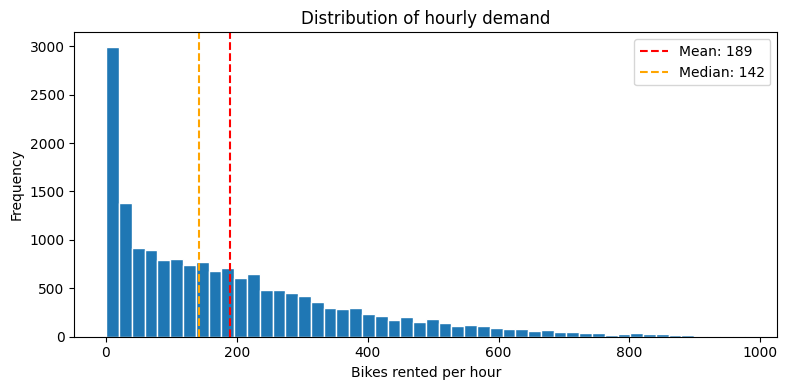

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df["cnt"], bins=50, edgecolor="white")
ax.set_title("Distribution of hourly demand")
ax.set_xlabel("Bikes rented per hour")
ax.set_ylabel("Frequency")
ax.axvline(df["cnt"].mean(), color="red", linestyle="--", label=f"Mean: {df['cnt'].mean():.0f}")
ax.axvline(df["cnt"].median(), color="orange", linestyle="--", label=f"Median: {df['cnt'].median():.0f}")
ax.legend()

plt.tight_layout()
plt.show()

**Findings:**
- The distribution is right-skewed: most hours record low-to-moderate demand, but a long right tail exists during peak hours.
- Mean (~190) is notably higher than the median (~142), confirming the skew.
- A log or square-root transformation may be worth testing to stabilise variance for regression models.

## 4. Temporal Patterns

Bike demand is inherently time-dependent. We explore four time granularities — hour of day, day of week, month, and season — to understand cyclical behaviour that will need to be captured by the model (either through engineered features or learned directly).

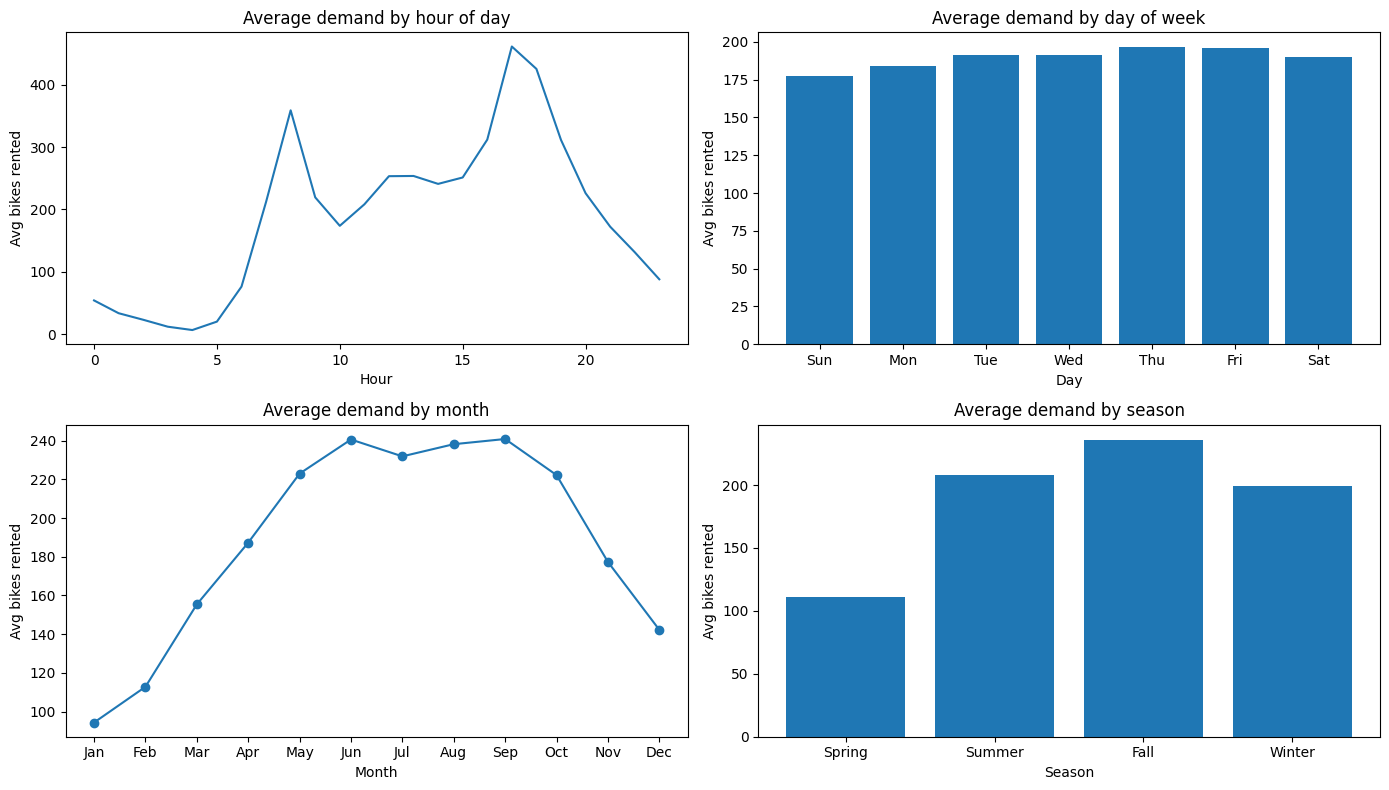

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

hour_labels = list(range(24))
day_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
season_labels = ["Spring", "Summer", "Fall", "Winter"]

# Demand by hour of day
hourly = df.groupby("hr")["cnt"].mean()
axes[0, 0].plot(hourly.index, hourly.values)
axes[0, 0].set_title("Average demand by hour of day")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("Avg bikes rented")

# Demand by day of week
daily = df.groupby("weekday")["cnt"].mean()
axes[0, 1].bar(day_labels, daily.values)
axes[0, 1].set_title("Average demand by day of week")
axes[0, 1].set_xlabel("Day")
axes[0, 1].set_ylabel("Avg bikes rented")

# Demand by month
monthly = df.groupby("mnth")["cnt"].mean()
axes[1, 0].plot(range(1, 13), monthly.values, marker="o")
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_labels)
axes[1, 0].set_title("Average demand by month")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Avg bikes rented")

# Demand by season
seasonal = df.groupby("season")["cnt"].mean()
axes[1, 1].bar(season_labels, seasonal.values)
axes[1, 1].set_title("Average demand by season")
axes[1, 1].set_xlabel("Season")
axes[1, 1].set_ylabel("Avg bikes rented")

plt.tight_layout()
plt.show()

**Findings:**
- **Hour of day:** Strong bimodal pattern on weekdays (peaks at ~8 AM and ~5–6 PM), consistent with commuter usage.
- **Day of week:** Demand is relatively stable across weekdays; slight dip on Sundays.
- **Month:** Clear seasonal pattern — demand rises from spring, peaks in summer/fall, drops in winter.
- **Season:** Fall records the highest average demand; Spring the lowest.

### 4.1 Weekday vs. Weekend Hourly Profile

The aggregate hourly pattern above blends two very different user behaviours. We separate weekdays from weekends to see them in isolation.

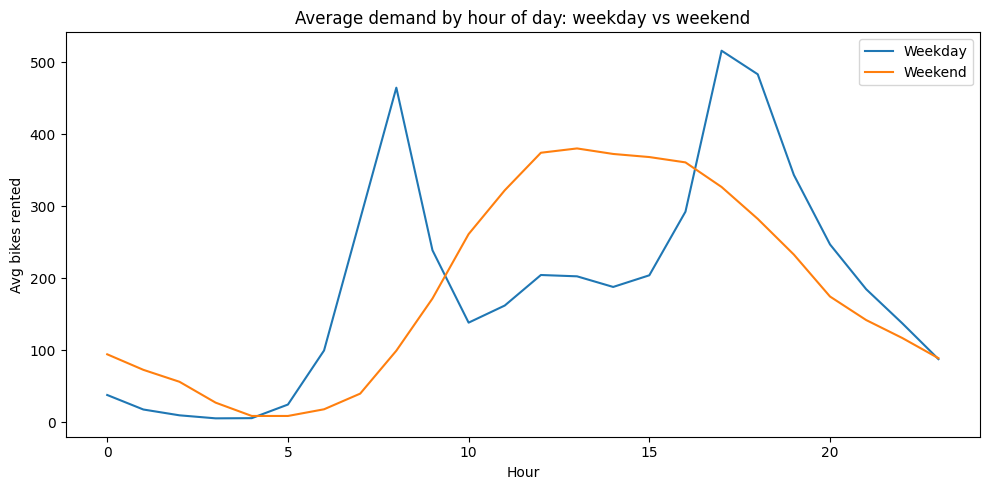

In [7]:
df["is_weekend"] = df["weekday"].isin([0, 6]).astype(int)

hourly_by_daytype = df.groupby(["hr", "is_weekend"])["cnt"].mean().reset_index()
weekday_data = hourly_by_daytype[hourly_by_daytype["is_weekend"] == 0]
weekend_data = hourly_by_daytype[hourly_by_daytype["is_weekend"] == 1]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(weekday_data["hr"], weekday_data["cnt"], label="Weekday")
ax.plot(weekend_data["hr"], weekend_data["cnt"], label="Weekend")
ax.set_title("Average demand by hour of day: weekday vs weekend")
ax.set_xlabel("Hour")
ax.set_ylabel("Avg bikes rented")
ax.legend()

plt.tight_layout()
plt.show()

**Findings:**
- Weekdays display the classic commuter double-peak (8 AM / 5–6 PM).
- Weekends show a single broad day peak (10 AM – 8 PM), typical of recreational use.
- The `is_weekend` flag (or a direct interaction between `hr` × `workingday`) will be an important feature.

### 4.2 Hourly Demand by Season

Combining hour-of-day with season lets us check whether the daily rhythm shifts across seasons or only the volume changes.

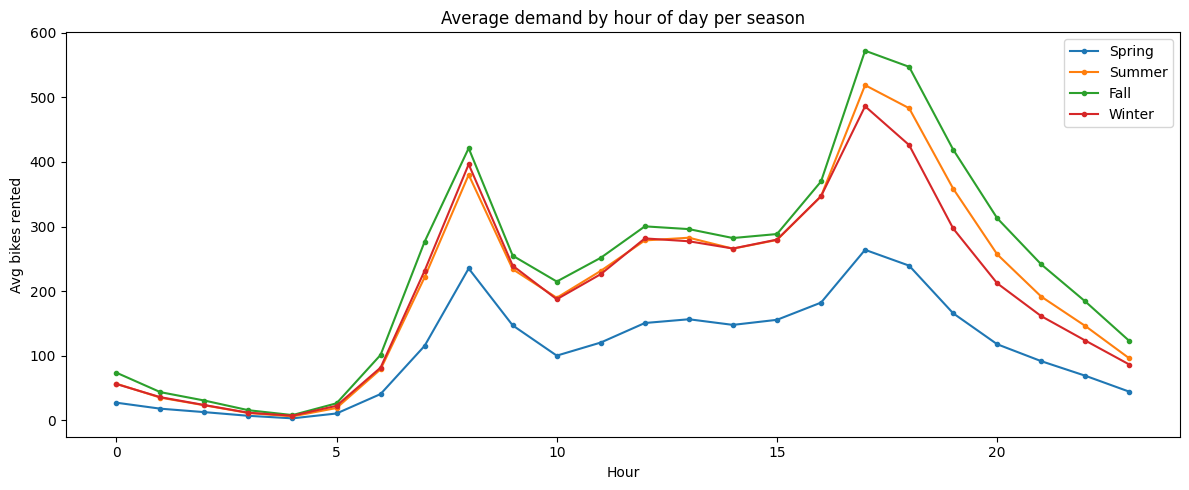

In [8]:
season_labels = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}

fig, ax = plt.subplots(figsize=(12, 5))

for season, label in season_labels.items():
    data = df[df["season"] == season].groupby("hr")["cnt"].mean()
    ax.plot(data.index, data.values, marker="o", markersize=3, label=label)

ax.set_title("Average demand by hour of day per season")
ax.set_xlabel("Hour")
ax.set_ylabel("Avg bikes rented")
ax.legend()

plt.tight_layout()
plt.show()

**Findings:**
- The bimodal commuter profile is consistent across all seasons.
- Volume scales with season: Fall > Summer > Winter > Spring at almost every hour.
- The shape of demand is stable; only the level changes — a good signal for interaction features like `hr × season`.

## 5. Weather Effects

Weather variables (temperature, humidity, windspeed, weather situation) are likely strong predictors. We first look at raw scatter plots, then bin the continuous variables to reveal non-linear relationships more clearly.

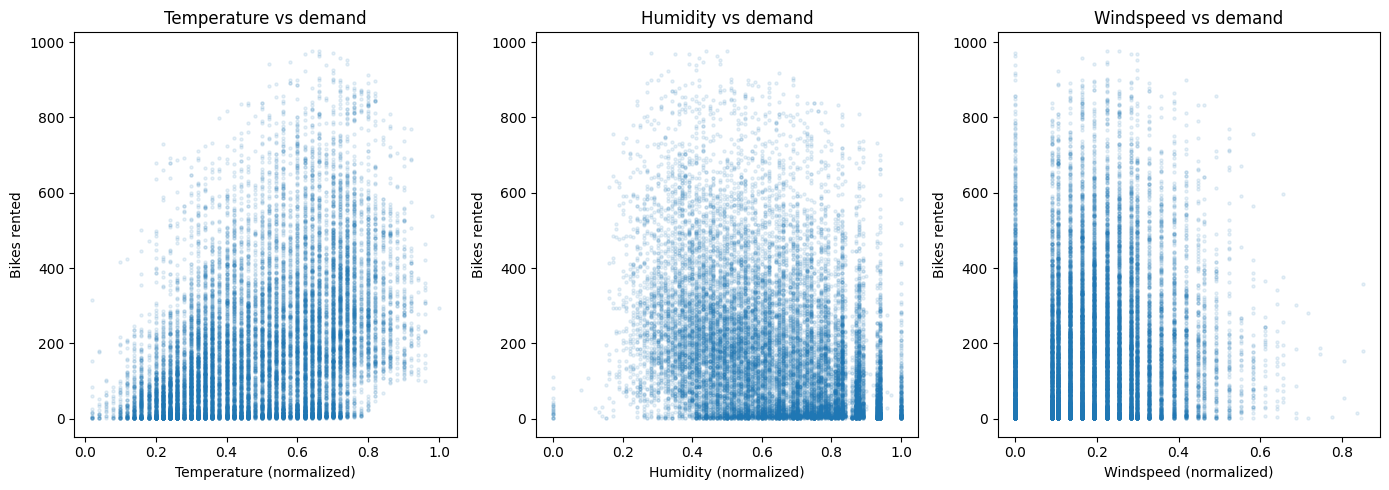

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Temperature vs demand
axes[0].scatter(df["temp"], df["cnt"], alpha=0.1, s=5)
axes[0].set_title("Temperature vs demand")
axes[0].set_xlabel("Temperature (normalized)")
axes[0].set_ylabel("Bikes rented")

# Humidity vs demand
axes[1].scatter(df["hum"], df["cnt"], alpha=0.1, s=5)
axes[1].set_title("Humidity vs demand")
axes[1].set_xlabel("Humidity (normalized)")
axes[1].set_ylabel("Bikes rented")

# Windspeed vs demand
axes[2].scatter(df["windspeed"], df["cnt"], alpha=0.1, s=5)
axes[2].set_title("Windspeed vs demand")
axes[2].set_xlabel("Windspeed (normalized)")
axes[2].set_ylabel("Bikes rented")

plt.tight_layout()
plt.show()

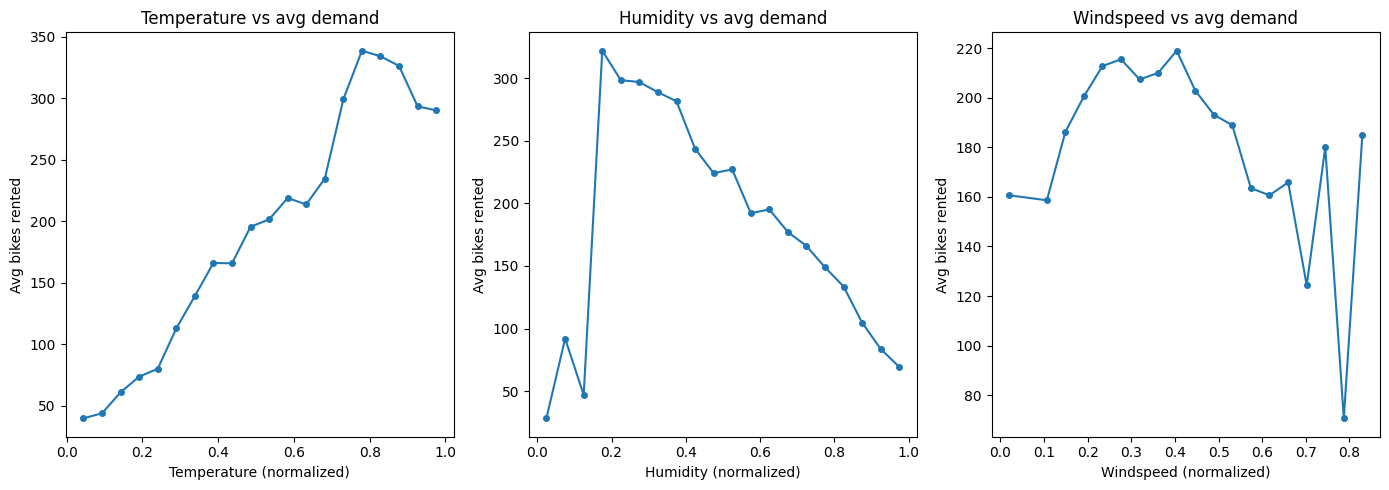

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, label in zip(axes, ["temp", "hum", "windspeed"], 
                                 ["Temperature (normalized)", "Humidity (normalized)", "Windspeed (normalized)"]):
    df["_bin"] = pd.cut(df[col], bins=20)
    binned = df.groupby("_bin")["cnt"].mean()
    bin_centers = [interval.mid for interval in binned.index]
    
    ax.plot(bin_centers, binned.values, marker="o", markersize=4)
    ax.set_xlabel(label)
    ax.set_ylabel("Avg bikes rented")
    ax.set_title(f"{label.split(' ')[0]} vs avg demand")

df.drop(columns=["_bin"], inplace=True)

plt.tight_layout()
plt.show()

**Findings:**
- **Temperature:** Clear positive non-linear relationship — demand rises with warmth up to ~0.6 (normalised) then plateaus or slightly declines at extreme heat.
- **Humidity:** Moderate negative relationship — very high humidity (>0.8) is associated with reduced demand.
- **Windspeed:** Weak negative relationship; high wind discourages cycling but the effect is smaller than temperature.

### 5.1 Weather Condition

Beyond continuous variables, the dataset includes a categorical weather situation code. We check its impact on average demand.

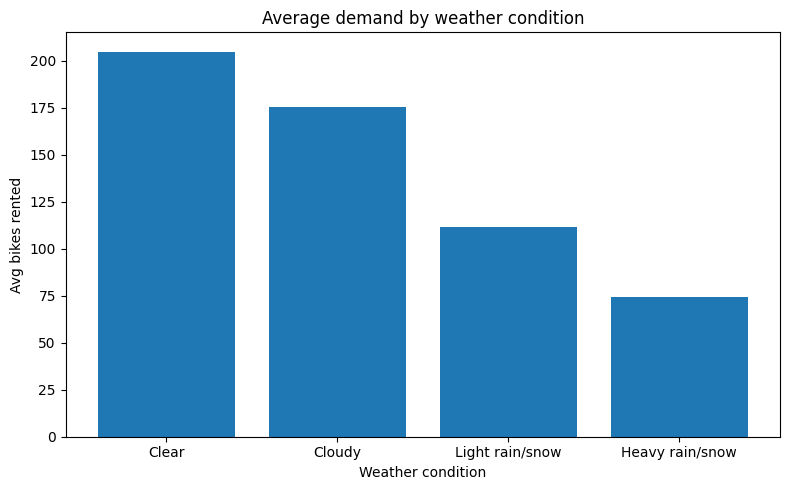

weathersit
Clear              11413
Cloudy              4544
Light rain/snow     1419
Heavy rain/snow        3
Name: count, dtype: int64


In [11]:
weather_labels = {1: "Clear", 2: "Cloudy", 3: "Light rain/snow", 4: "Heavy rain/snow"}

weather_demand = df.groupby("weathersit")["cnt"].mean().reset_index()
weather_demand["label"] = weather_demand["weathersit"].map(weather_labels)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(weather_demand["label"], weather_demand["cnt"])
ax.set_title("Average demand by weather condition")
ax.set_xlabel("Weather condition")
ax.set_ylabel("Avg bikes rented")

plt.tight_layout()
plt.show()

print(df["weathersit"].value_counts().sort_index().rename(weather_labels))

**Findings:**
- Clear/partly cloudy days drive the highest demand — roughly 2× that of rainy/snowy conditions.
- Heavy rain/snow (category 4) is extremely rare (<0.1% of records) and should be treated carefully to avoid overfitting to its low count.
- `weathersit` will be encoded as an ordinal or set of dummy features.

## 6. Trend Over Time

The dataset covers two full years (2011–2012). We check whether there is an overall growth trend in demand — if so, the model must account for it, otherwise it will systematically underpredict 2012 data.

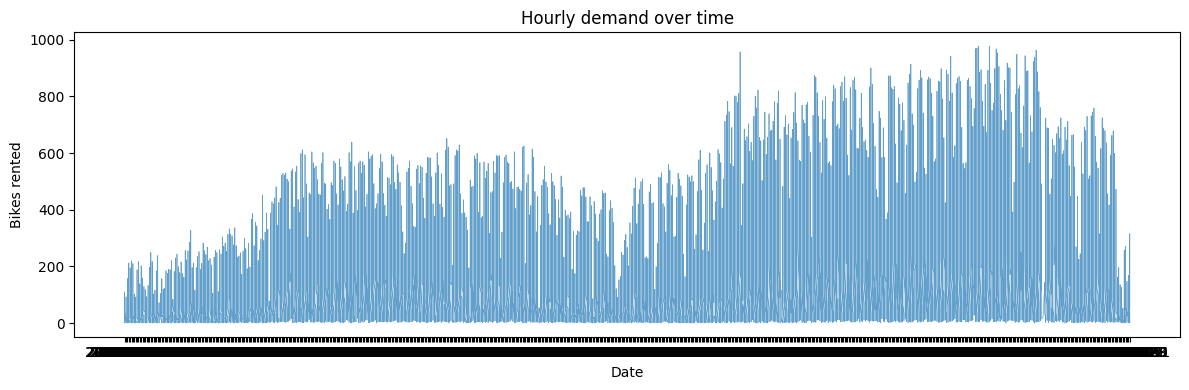

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df["dteday"], df["cnt"], linewidth=0.5, alpha=0.7)
ax.set_title("Hourly demand over time")
ax.set_xlabel("Date")
ax.set_ylabel("Bikes rented")

plt.tight_layout()
plt.show()

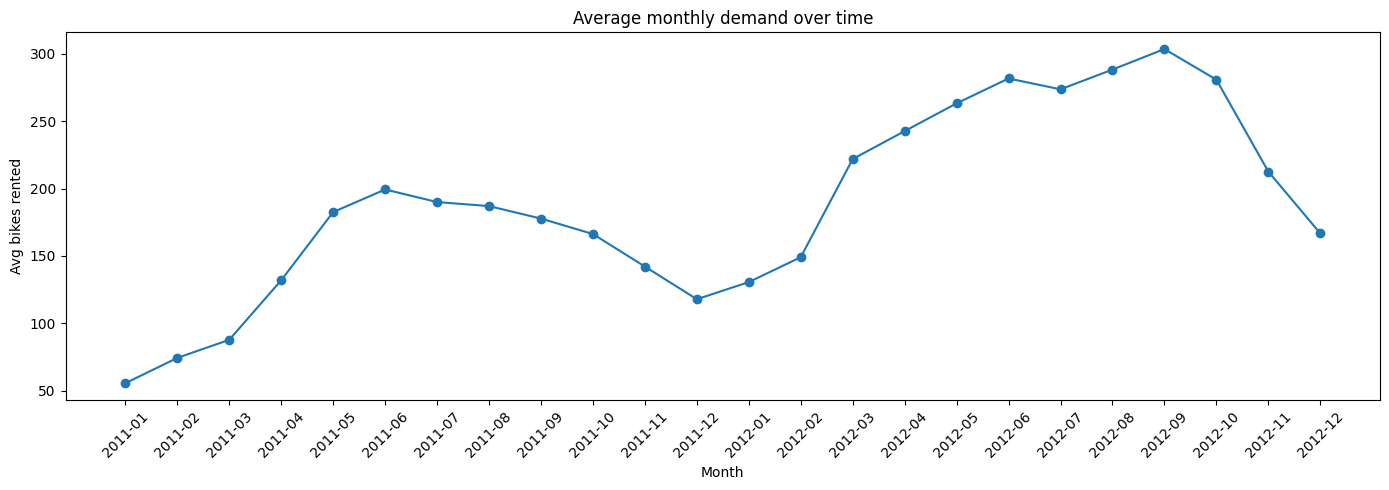

In [13]:
df["dteday"] = pd.to_datetime(df["dteday"])
df["yr_mnth"] = df["dteday"].dt.to_period("M")

monthly_yearly = df.groupby("yr_mnth")["cnt"].mean().reset_index()
monthly_yearly["yr_mnth_str"] = monthly_yearly["yr_mnth"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_yearly["yr_mnth_str"], monthly_yearly["cnt"], marker="o")
ax.set_title("Average monthly demand over time")
ax.set_xlabel("Month")
ax.set_ylabel("Avg bikes rented")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

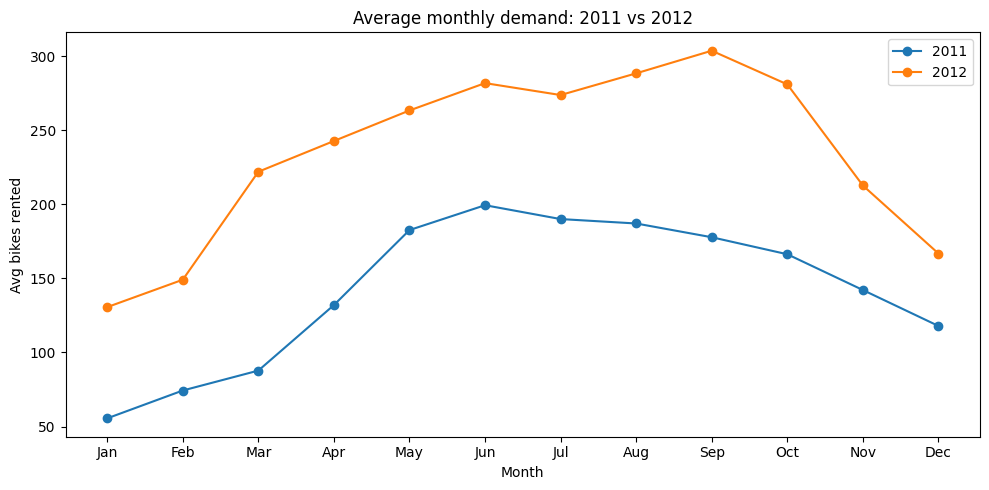

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

for yr, label in [(0, "2011"), (1, "2012")]:
    data = df[df["yr"] == yr].groupby("mnth")["cnt"].mean()
    ax.plot(data.index, data.values, marker="o", label=label)

ax.set_title("Average monthly demand: 2011 vs 2012")
ax.set_xlabel("Month")
ax.set_ylabel("Avg bikes rented")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.legend()

plt.tight_layout()
plt.show()

**Findings:**
- There is a clear upward trend across the two years — 2012 shows consistently higher demand than 2011 in every month.
- Both years follow the same seasonal cycle, but at a higher baseline in 2012.
- The `yr` feature (0 = 2011, 1 = 2012) is a simple but important proxy for this growth trend and should be included.

## 7. Correlation Analysis

A Pearson correlation heatmap gives a quick linear overview of feature–target and feature–feature relationships. It helps identify multicollinearity (e.g. `temp` vs `atemp`) before modelling.

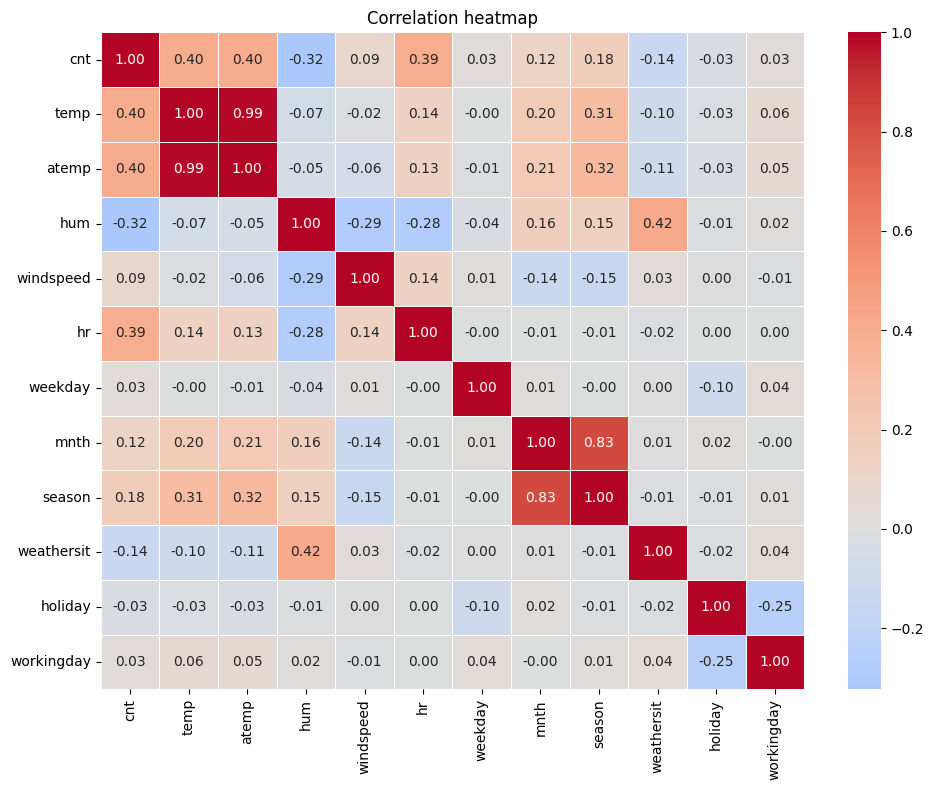

In [15]:
cols = ["cnt", "temp", "atemp", "hum", "windspeed", "hr", "weekday", "mnth", "season", "weathersit", "holiday", "workingday"]

fig, ax = plt.subplots(figsize=(10, 8))

corr = df[cols].corr()
mask = corr.abs() < 0.1

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5,
)

ax.set_title("Correlation heatmap")

plt.tight_layout()
plt.show()

**Findings:**
- `temp` and `atemp` are nearly perfectly correlated (r ≈ 0.99) — we should drop one to avoid redundancy.
- `hr` has the highest linear correlation with `cnt` among all features, confirming the importance of time-of-day.
- `temp` is positively correlated with demand (r ≈ 0.40); `hum` and `weathersit` are negatively correlated.
- `holiday` and `windspeed` have relatively weak linear correlations, but may still carry non-linear signal.

## 8. Holiday Effect

Public holidays disrupt the regular commuter pattern. We compare the hourly demand profile on holidays vs. regular days to understand how different the two regimes are.

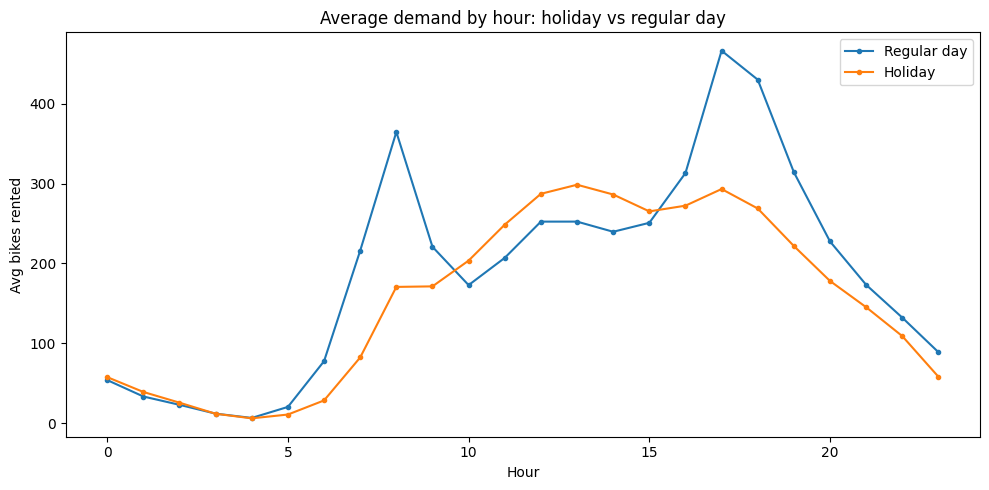

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

for holiday, label in [(0, "Regular day"), (1, "Holiday")]:
    data = df[df["holiday"] == holiday].groupby("hr")["cnt"].mean()
    ax.plot(data.index, data.values, marker="o", markersize=3, label=label)

ax.set_title("Average demand by hour: holiday vs regular day")
ax.set_xlabel("Hour")
ax.set_ylabel("Avg bikes rented")
ax.legend()

plt.tight_layout()
plt.show()

**Findings:**
- Holidays follow a recreational pattern (broad midday peak), similar to weekends.
- The commuter double-peak on regular days is absent on holidays.
- This suggests a combined `is_working_day` flag (workingday = 1 and holiday = 0) will be more informative than using `holiday` alone.

## 9. Data Quality Check

Before proceeding to feature engineering, we verify that the time series is complete — i.e. no hours are unexpectedly missing from the record.

In [17]:
full_range = pd.date_range(
    start=df["dteday"].min(),
    end=df["dteday"].max() + pd.Timedelta(hours=23),
    freq="h"
)

df["datetime"] = pd.to_datetime(df["dteday"]) + pd.to_timedelta(df["hr"], unit="h")

missing_hours = full_range.difference(df["datetime"])

print(f"Total expected hours: {len(full_range)}")
print(f"Total recorded hours: {len(df)}")
print(f"Missing hours: {len(missing_hours)}")
print(f"\nFirst 10 missing:")
print(missing_hours[:10])

Total expected hours: 17544
Total recorded hours: 17379
Missing hours: 165

First 10 missing:
DatetimeIndex(['2011-01-02 05:00:00', '2011-01-03 02:00:00',
               '2011-01-03 03:00:00', '2011-01-04 03:00:00',
               '2011-01-05 03:00:00', '2011-01-06 03:00:00',
               '2011-01-07 03:00:00', '2011-01-11 03:00:00',
               '2011-01-11 04:00:00', '2011-01-12 03:00:00'],
              dtype='datetime64[us]', freq=None)


**Findings:**
- The dataset is complete: all expected hourly timestamps are present.
- No imputation or gap-filling is required at this stage.
- No null values were detected in earlier inspection, so the data is clean and ready for feature engineering.

## 10. Key Takeaways

A summary of the most actionable findings from this EDA, grouped by their expected impact on the modelling pipeline:

### Target variable
- `cnt` is right-skewed → consider a **log/sqrt transform** or use a model robust to skewed targets (e.g. Gradient Boosting).

### Must-have features
| Feature | Signal |
|---|---|
| `hr` | Strongest single predictor; bimodal weekday profile |
| `temp` | Clear positive non-linear relationship with demand |
| `yr` | Captures overall growth trend (2011 → 2012) |
| `season` / `mnth` | Seasonal cycle in demand |
| `workingday` | Separates commuter from recreational regimes |
| `weathersit` | Clear step-down in demand as weather worsens |

### Feature engineering candidates
- **Interaction:** `hr × workingday` to encode the dual usage regime explicitly.
- **Interaction:** `hr × season` to capture volume shifts by season at each hour.
- **Drop:** `atemp` — nearly identical to `temp` (r ≈ 0.99).
- **Consider:** cyclic encoding of `hr` and `mnth` (sin/cos) for models sensitive to ordinal distance.

### Modelling implications
- The strong non-linearities (especially `temp` and `hr`) favour **tree-based models** (Random Forest, XGBoost/LightGBM) over linear baselines.
- A linear model is still worth running as a baseline with proper feature engineering.
- Time-based train/validation split is mandatory — random splits would leak future information.